In [12]:
import pandas as pd
print("Cargando el dataset...")
df = pd.read_csv('data/ec_properties.csv', low_memory=False)
# Filtrar para quedarnos con la ciudad de Quito
df_quito = df[(df['l1'] == 'Ecuador') & (df['l2'] == 'Pichincha') & (df['l3'] == 'Quito')].copy()
print(f"¡Listo! Tenemos {df_quito.shape[1]} propiedades en Quito para analizar.")
display(df_quito.head())

Cargando el dataset...
¡Listo! Tenemos 25 propiedades en Quito para analizar.


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,puTf6SJMm87RSQKD7PfZHQ==,Propiedad,2019-11-16,9999-12-31,2019-11-16,-0.190255,-78.481672,Ecuador,Pichincha,Quito,...,NaN,100.0,15.0,280.0,USD,Mensual,Oficina / consultorio alquiler,Oficina de renta. Varios espacios compartidos ...,Oficina,Alquiler
1,Ikdxz61f/OO1ltcy74G9xQ==,Propiedad,2019-11-16,2020-02-08,2019-11-16,-0.184508,-78.480689,Ecuador,Pichincha,Quito,...,NaN,69.0,69.0,485.0,USD,Mensual,Departamentos alquiler,Suite de renta amoblada Av. República del Salv...,Departamento,Alquiler
8,gdgSQxXi2hfaA90JxeJqzQ==,Propiedad,2019-09-13,2019-11-27,2019-09-13,-0.319000,-78.464996,Ecuador,Pichincha,Quito,...,3.0,120.0,NaN,110000.0,USD,NaN,Venta de Casa en Capelo. 3 Plantas en Conjunto...,Venta de Casa en Capelo. 3 Plantas en Conjunto...,Casa,Venta
9,XkbPRotzdF7fDBAlRAX0Aw==,Propiedad,2019-09-13,2019-11-27,2019-09-13,NaN,NaN,Ecuador,Pichincha,Quito,...,NaN,600.0,NaN,4250000.0,USD,NaN,"Puembo, 5 Hectáreas de Terreno, San Jose de Pu...",Venta 5 Hectáreas Planas en San Jose de Puembo...,Lote,Venta
11,HDkjmBal0oXyIsvz7aOg8A==,Propiedad,2019-09-13,2019-11-27,2019-09-13,NaN,NaN,Ecuador,Pichincha,Quito,...,NaN,600.0,NaN,300000.0,USD,NaN,Puembo 1.668 m2. Urbanizacion Montana Sector A...,ul<br> liEspectacular terreno de 1.668 m2. en ...,Otro,Venta


In [ ]:
# Limpieza 
# Filtrar estrictamente Ventas y solo viviendas residenciales, ignoramos Oficinas, Lotes o Locales
df_viviendas = df_quito[(df_quito['operation_type'] == 'Venta') & 
                        (df_quito['property_type'].isin(['Casa', 'Departamento']))].copy()

# Seleccionar solo las columnas que impactan el precio de una vivienda
columnas_clave = ['lat', 'lon', 'property_type', 'bathrooms', 'surface_total', 'surface_covered', 'price']
df_limpio = df_viviendas[columnas_clave].copy()

# Eliminar filas que sean absolutamente inútiles
df_limpio = df_limpio.dropna(subset=['price', 'lat', 'lon'])

print(f"Propiedades residenciales listas para el análisis: {df_limpio.shape[0]}")
print("\nPorcentaje de datos faltantes (NaN) por columna:")
porcentaje_nulos = (df_limpio.isnull().sum() / len(df_limpio)) * 100
print(porcentaje_nulos.round(2).astype(str) + ' %')

display(df_limpio.head())

Propiedades residenciales listas para el análisis: 17518

Porcentaje de datos faltantes (NaN) por columna:
lat                  0.0 %
lon                  0.0 %
property_type        0.0 %
bathrooms           2.27 %
surface_total      32.84 %
surface_covered    99.42 %
price                0.0 %
dtype: str


,lat,lon,property_type,bathrooms,surface_total,surface_covered,price
8,-0.319,-78.464996,Casa,3.0,120.0,NaN,110000.0
310,-0.140,-78.500000,Departamento,2.0,118.0,NaN,75000.0
312,-0.166,-78.494003,Departamento,2.0,234.0,NaN,200000.0
316,-0.318,-78.549004,Departamento,1.0,65.0,NaN,39500.0
317,-0.232,-78.336998,Casa,3.0,1800.0,NaN,360000.0


In [ ]:
# Limpieza 2
df_limpio = df_limpio.drop(columns=['surface_covered'])
# Rellenar baños faltantes con la mediana según el tipo de propiedad
df_limpio['bathrooms'] = df_limpio.groupby('property_type')['bathrooms'].transform(lambda x: x.fillna(x.median()))
# Eliminar filas sin surface_total para trabajar solo con áreas reales
df_limpio = df_limpio.dropna(subset=['surface_total'])
# Quitar propiedades con errores de tipeo
df_final = df_limpio[(df_limpio['surface_total'] >= 20) & (df_limpio['price'] >= 10000)].copy()

print(f"¡Limpieza impecable! Dataset final listo para Machine Learning: {df_final.shape[0]} propiedades.")
print("\nComprobación de nulos (deberían ser puros ceros):")
print(df_final.isnull().sum())

display(df_final.head())

¡Limpieza impecable! Dataset final listo para Machine Learning: 11746 propiedades.

Comprobación de nulos (deberían ser puros ceros):
lat              0
lon              0
property_type    0
bathrooms        0
surface_total    0
price            0
dtype: int64


,lat,lon,property_type,bathrooms,surface_total,price
8,-0.319,-78.464996,Casa,3.0,120.0,110000.0
310,-0.140,-78.500000,Departamento,2.0,118.0,75000.0
312,-0.166,-78.494003,Departamento,2.0,234.0,200000.0
316,-0.318,-78.549004,Departamento,1.0,65.0,39500.0
317,-0.232,-78.336998,Casa,3.0,1800.0,360000.0


Matplotlib is building the font cache; this may take a moment.


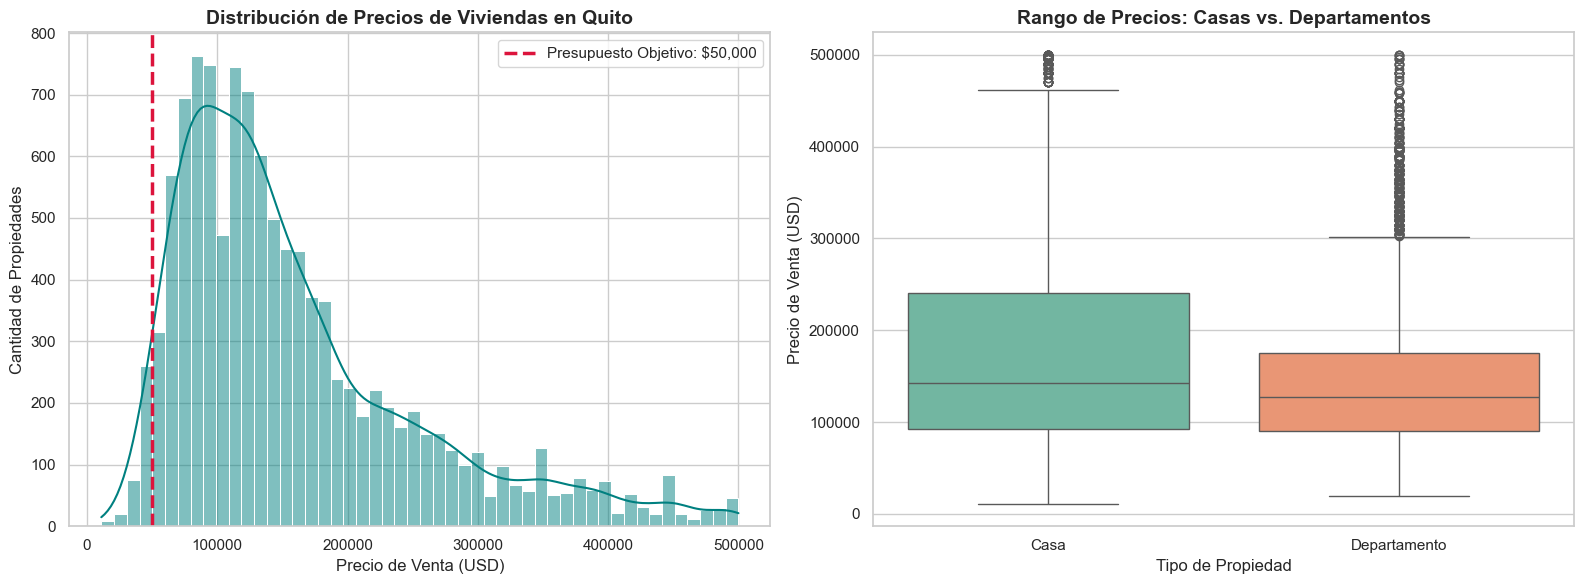

In [ ]:
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_mercado = df_final[df_final['price'] <= 500000]

# Creo el lienzo para dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1 Distribución general de precios
sns.histplot(data=df_mercado, x='price', bins=50, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribución de Precios de Viviendas en Quito', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio de Venta (USD)', fontsize=12)
axes[0].set_ylabel('Cantidad de Propiedades', fontsize=12)

axes[0].axvline(x=50000, color='crimson', linestyle='--', linewidth=2.5, label='Presupuesto Objetivo: $50,000')
axes[0].legend()

#  GRÁFICO 2 Casas vs Departamentos
sns.boxplot(data=df_mercado, x='property_type', y='price', hue='property_type', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Rango de Precios: Casas vs. Departamentos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tipo de Propiedad', fontsize=12)
axes[1].set_ylabel('Precio de Venta (USD)', fontsize=12)

plt.tight_layout()

In [ ]:
import folium

df_objetivo = df_final[(df_final['price'] >= 40000) & (df_final['price'] <= 60000)].copy()

# Creo el mapa base centrado en Quito
mapa_quito = folium.Map(location=[-0.18, -78.48], zoom_start=12, tiles='cartodbpositron')

muestra_mapa = df_objetivo.sample(n=min(500, len(df_objetivo)), random_state=42)

for index, row in muestra_mapa.iterrows():

    color_marcador = 'blue' if row['property_type'] == 'Departamento' else 'green'
    
    popup_text = f"<b>{row['property_type']}</b><br>Precio: ${row['price']:,.0f}<br>Área: {row['surface_total']} m2<br>Baños: {row['bathrooms']}"
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        popup=folium.Popup(popup_text, max_width=250),
        color=color_marcador,
        fill=True,
        fill_color=color_marcador,
        fill_opacity=0.7
    ).add_to(mapa_quito)

print(f"Mostrando {len(muestra_mapa)} propiedades en Quito con precios entre $40k y $60k.")
print("🟢 Verde = Casas | 🔵 Azul = Departamentos")
mapa_quito

# Guardar el mapa, se crea un arcivo aparte
mapa_quito.save('mapa_oportunidades_quito.html')

Mostrando 500 propiedades en Quito con precios entre $40k y $60k.
🟢 Verde = Casas | 🔵 Azul = Departamentos


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

df_ml = pd.get_dummies(df_final, columns=['property_type'], drop_first=True)

X = df_ml.drop('price', axis=1)
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo 
print("Entrenando la Inteligencia Artificial...")
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
error_medio = mean_absolute_error(y_test, predicciones)
precision = r2_score(y_test, predicciones)

print("\nModelo entrenado con éxito")
print(f"Margen de error promedio: ${error_medio:,.2f}")
print(f"Puntuación de precisión (R2): {precision:.2f} (Más cerca de 1 es mejor)")

#  Encontrar oportunidades de inversión
print("\nBuscando 'ofertas' inmobiliarias en Quito...")

# Juntar los precios reales con los que predijo la IA
resultados = X_test.copy()
resultados['Precio_Real'] = y_test
resultados['Precio_Predicho'] = predicciones.round(2)
resultados['Ahorro_Estimado'] = resultados['Precio_Predicho'] - resultados['Precio_Real']

gangas = resultados[(resultados['Precio_Real'] <= 55000) & (resultados['Ahorro_Estimado'] >= 10000)]
gangas = gangas.sort_values(by='Ahorro_Estimado', ascending=False)

print(f"\n¡Se encontraron {len(gangas)} propiedades infravaloradas!")
display(gangas[['Precio_Real', 'Precio_Predicho', 'Ahorro_Estimado', 'surface_total', 'bathrooms']].head(10))

Entrenando la Inteligencia Artificial...

¡Modelo entrenado con éxito!
Margen de error promedio: $52,556.47
Puntuación de precisión (R2): 0.25 (Más cerca de 1 es mejor)

Buscando 'ofertas' inmobiliarias en Quito...

¡Se encontraron 53 propiedades infravaloradas!


,Precio_Real,Precio_Predicho,Ahorro_Estimado,surface_total,bathrooms
20616,52000.0,314490.32,262490.32,950.0,2.0
82711,46000.0,140157.12,94157.12,65.0,3.0
76334,25000.0,111180.03,86180.03,110.0,2.0
133337,39000.0,122761.00,83761.00,140.0,3.0
139849,43000.0,115530.74,72530.74,67.0,1.0
135050,45000.0,116150.67,71150.67,180.0,3.0
82686,45000.0,113248.39,68248.39,60.0,1.0
66621,46000.0,108646.04,62646.04,58.0,1.0
84051,38000.0,92394.48,54394.48,57.0,2.0
1417,42000.0,96342.17,54342.17,89.0,1.0
